In [18]:
import numpy as np
import pandas as pd
import hdbscan

In [19]:
df = pd.read_csv(r"dataset\preprocessing\prePro-news_filtered.csv")
embeddings = np.load(r"dataset\fineTuned\embeddings\unbalanced_episode_embeddings.npy")
df['timestamp'] = pd.to_datetime(df['published_date'])

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: (5120, 385)


## Episode Discovery using HDBSCAN

In [20]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric='euclidean'
)

labels = clusterer.fit_predict(embeddings)

print("Unique Clusters:", np.unique(labels))

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Unique Clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56]


In [21]:
df['episode'] = labels

print(df['episode'].value_counts())

-1     3416
 38     205
 56     159
 53     148
 45     122
 20     112
 49      73
 24      73
 50      49
 16      43
 30      38
 47      38
 34      34
 41      33
 5       30
 52      26
 1       25
 19      21
 35      21
 51      21
 31      20
 48      19
 11      19
 26      17
 21      17
 6       17
 39      15
 13      15
 25      14
 32      14
 17      13
 4       12
 12      12
 37      11
 28      11
 0       11
 40      11
 15      11
 14      10
 2       10
 42      10
 10      10
 54      10
 33      10
 44       9
 36       9
 9        8
 46       8
 27       8
 29       8
 55       8
 8        8
 23       8
 43       8
 3        8
 22       8
 18       8
 7        8
Name: episode, dtype: int64


## Dimentionality Reduction

In [22]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

print("UMAP Shape:", embedding_2d.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP Shape: (5120, 2)


## Episode cluster visualization

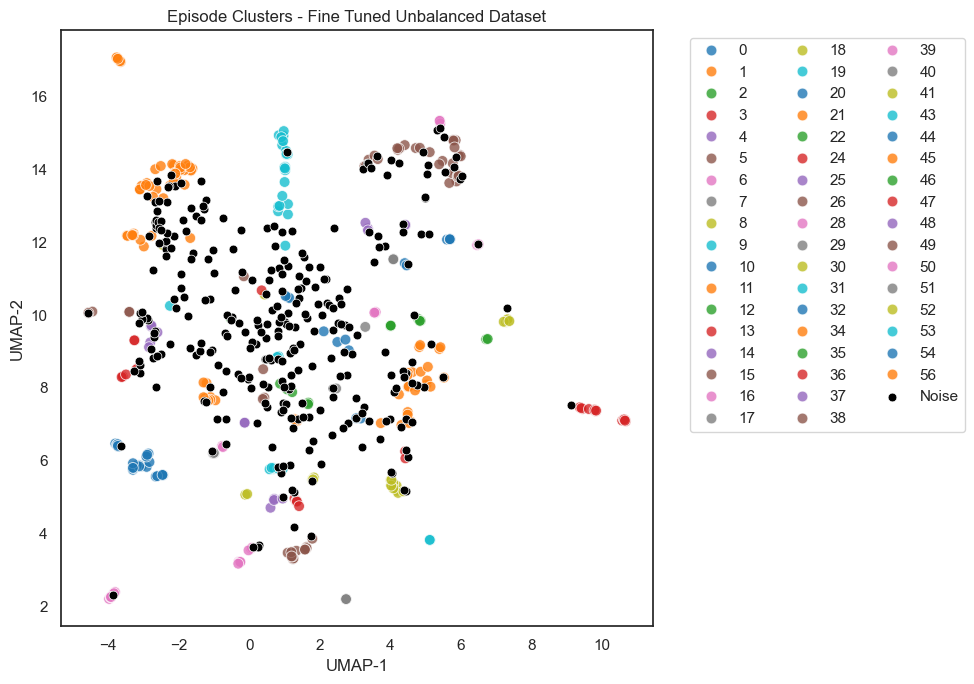

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
plt.style.use('default')
sns.set_theme(style="white", palette="deep")

cluster_idx = np.where(labels != -1)[0]
cluster_sample = np.random.choice(cluster_idx, size=350, replace=False)

noise_idx = np.where(labels == -1)[0]
noise_sample = np.random.choice(noise_idx, size=min(300, len(noise_idx)), replace=False)

final_idx = np.concatenate([cluster_sample, noise_sample])

sns.scatterplot(
    x=embedding_2d[cluster_sample, 0],
    y=embedding_2d[cluster_sample, 1],
    hue=labels[cluster_sample],
    palette="tab10",
    s=60,
    alpha=0.8,
    legend=True
)

sns.scatterplot(
    x=embedding_2d[noise_sample, 0],
    y=embedding_2d[noise_sample, 1],
    color="black",
    s=40,
    label="Noise"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    ncol= 3
)

plt.title("Episode Clusters - Fine Tuned Unbalanced Dataset")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.tight_layout()
plt.show()

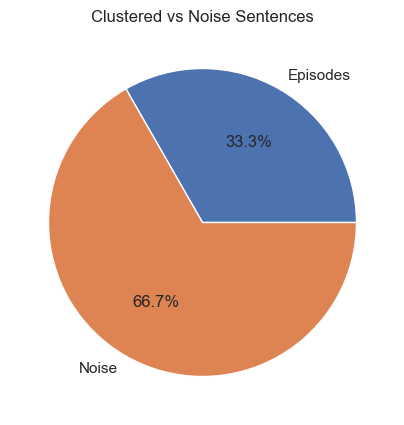

In [24]:
noise = np.sum(labels == -1)
clustered = np.sum(labels != -1)

plt.figure(figsize=(5,5))
plt.pie(
    [clustered, noise],
    labels=["Episodes", "Noise"],
    autopct='%1.1f%%'
)
plt.title("Clustered vs Noise Sentences")
plt.show()

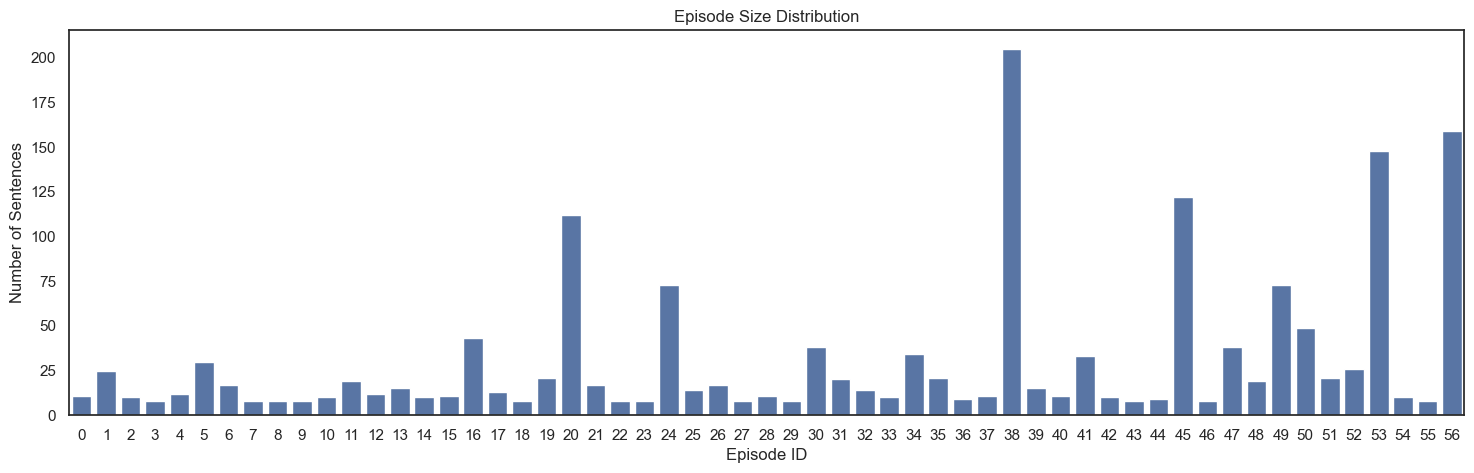

In [25]:
episode_sizes = df[df['episode'] != -1]['episode'].value_counts()

plt.figure(figsize=(18,5))
sns.barplot(
    x=episode_sizes.index,
    y=episode_sizes.values
)

plt.title("Episode Size Distribution")
plt.xlabel("Episode ID")
plt.ylabel("Number of Sentences")
plt.show()

In [26]:
t0 = df['timestamp'].min()
df['t'] = (df['timestamp'] - t0).dt.days
df['t_norm'] = df['t'] / df['t'].max()

In [27]:
episode_time_spread = df[df['episode'] != -1].groupby('episode')['t_norm'].std()

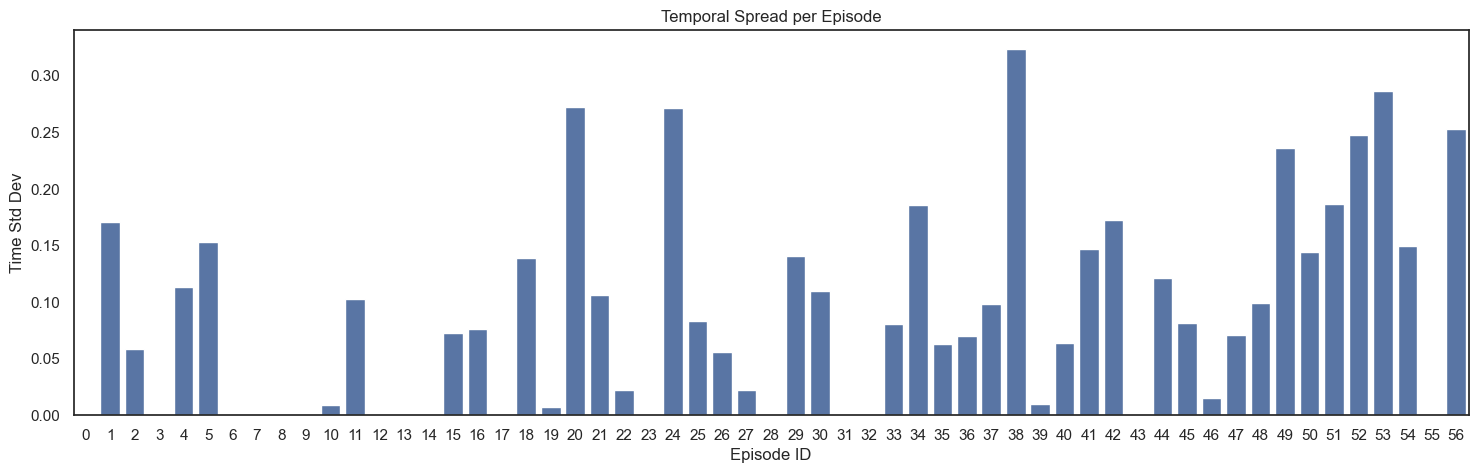

In [28]:
plt.figure(figsize=(18,5))
sns.barplot(
    x=episode_time_spread.index,
    y=episode_time_spread.values
)

plt.title("Temporal Spread per Episode")
plt.xlabel("Episode ID")
plt.ylabel("Time Std Dev")
plt.show()

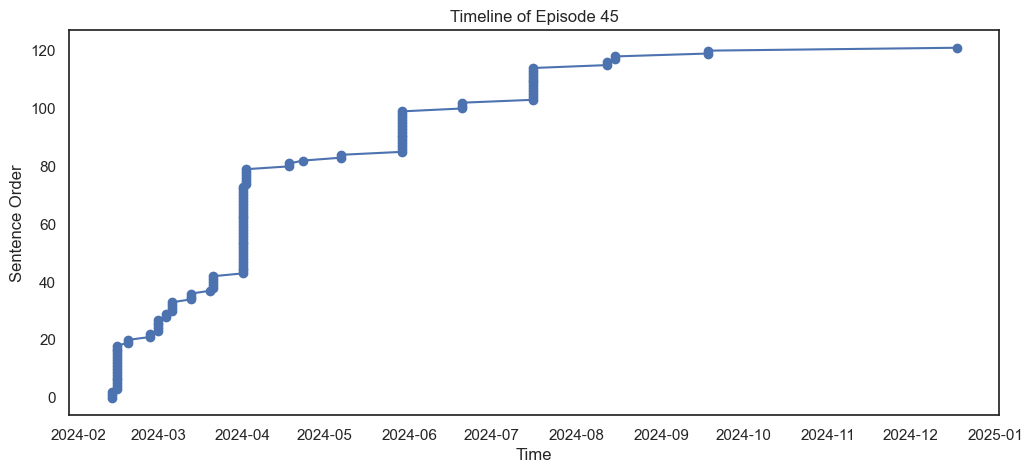

In [29]:
episode_id = 45

episode_df = df[df['episode'] == episode_id].sort_values('timestamp')

plt.figure(figsize=(12,5))
plt.plot(episode_df['timestamp'], range(len(episode_df)), marker='o')

plt.title(f"Timeline of Episode {episode_id}")
plt.xlabel("Time")
plt.ylabel("Sentence Order")
plt.show()

## Semantic Coherence Check

In [30]:
sample = df[df['episode'] == episode_id]['sentence'].sample(5, random_state=42)

for s in sample:
    print("-", s)

- Chief Assistant Prosecuting Attorney Kyle Attwood said the sentence "is what we were hoping Attwood said he has prosecuted a lot of sex-offense cases, but said this case was unique because it involved an entire community. "We have dealt with hidden camera type cases before," he said, "But, typically, it's a specific person who is targeted, not something that operates 24/7 and picks up multiple individuals.
- A man is accused of planting a hidden camera in his neighbour’s apartment, and Pennsylvania authorities say he may have done the same to others.
- Police said Selleny, who lives in the same King of Prussia apartment complex as the victim, broke into her home “on several occasions” and planted the hidden camera.
- Investigators found Sherwood had placed a hidden camera in a wall outlet at another home in Jefferson County, Keller said.
- He told her he uses the camera to prevent thefts from his studio during lessons, but the woman told investigators she did not believe his explanat

In [31]:
episode_time = df[df['episode'] == episode_id]['timestamp']

print("Start:", episode_time.min())
print("End:", episode_time.max())

Start: 2024-02-13 00:00:00
End: 2024-12-18 00:00:00


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df[df['episode'] == episode_id]['sentence']

vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
X = vectorizer.fit_transform(texts)

print(vectorizer.get_feature_names_out())

['according' 'bathroom' 'camera' 'cameras' 'devices' 'hidden' 'police'
 'privacy' 'recording' 'said']


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

indices = df[df['episode'] == episode_id].index
cluster_embeddings = embeddings[indices]

sim = cosine_similarity(cluster_embeddings)

print("Average Similarity:", sim.mean())

Average Similarity: 0.7104404703452031


In [34]:
episode_df["orig_index"] = episode_df.index

episode_df[
    ["orig_index", "content_id", "sentence", "published_date", "category", "episode"]
].to_csv(r"dataset\fineTuned\episodes\episode_unbalanced.csv",index=False)